In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv(
    '../data/raw/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

In [3]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

In [4]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [5]:
df = df.apply(pd.to_numeric)
df.interpolate(method='time', inplace=True)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0


In [6]:
energy_hourly = df['Global_active_power'].resample('h').mean()
energy_hourly.interpolate(method='time', inplace=True)

datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
                         ...   
2010-11-26 17:00:00    1.725900
2010-11-26 18:00:00    1.573467
2010-11-26 19:00:00    1.659333
2010-11-26 20:00:00    1.163700
2010-11-26 21:00:00    0.934667
Freq: h, Name: Global_active_power, Length: 34589, dtype: float64

In [7]:
prophet_df = energy_hourly.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_df

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467
...,...,...
34584,2010-11-26 17:00:00,1.725900
34585,2010-11-26 18:00:00,1.573467
34586,2010-11-26 19:00:00,1.659333
34587,2010-11-26 20:00:00,1.163700


### Prophet Model Training

Prophet is used to model time series data with strong seasonality and trend components. It automatically handles daily and weekly seasonality.

In [8]:
train_size = int(len(prophet_df) * 0.9)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

In [9]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

d:\AI Engineer Career\ClaySys\Energy_Consumption_Forecasting_Project\energy-consumption-forecasting-timeseries\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
12:47:17 - cmdstanpy - INFO - Chain [1] start processing
12:47:23 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(periods=len(test), freq='h')

future

,ds
0,2006-12-16 17:00:00
1,2006-12-16 18:00:00
2,2006-12-16 19:00:00
3,2006-12-16 20:00:00
4,2006-12-16 21:00:00
...,...
34584,2010-11-26 17:00:00
34585,2010-11-26 18:00:00
34586,2010-11-26 19:00:00
34587,2010-11-26 20:00:00


In [11]:
forecast = model.predict(future)

forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2006-12-16 17:00:00,1.399512,0.754645,2.682861,1.399512,1.399512,0.393381,0.393381,0.393381,-0.075798,...,0.170849,0.170849,0.170849,0.298329,0.298329,0.298329,0.0,0.0,0.0,1.792893
1,2006-12-16 18:00:00,1.399380,1.220439,3.073483,1.399380,1.399380,0.755424,0.755424,0.755424,0.278551,...,0.178292,0.178292,0.178292,0.298581,0.298581,0.298581,0.0,0.0,0.0,2.154804
2,2006-12-16 19:00:00,1.399248,1.682832,3.498493,1.399248,1.399248,1.169555,1.169555,1.169555,0.685618,...,0.185103,0.185103,0.185103,0.298834,0.298834,0.298834,0.0,0.0,0.0,2.568803
3,2006-12-16 20:00:00,1.399116,1.820260,3.690480,1.399116,1.399116,1.369142,1.369142,1.369142,0.878827,...,0.191226,0.191226,0.191226,0.299089,0.299089,0.299089,0.0,0.0,0.0,2.768258
4,2006-12-16 21:00:00,1.398984,1.695276,3.533739,1.398984,1.398984,1.216005,1.216005,1.216005,0.720054,...,0.196607,0.196607,0.196607,0.299344,0.299344,0.299344,0.0,0.0,0.0,2.614989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34584,2010-11-26 17:00:00,1.117290,0.436884,2.320208,1.060034,1.170881,0.253907,0.253907,0.253907,-0.075798,...,-0.045299,-0.045299,-0.045299,0.375004,0.375004,0.375004,0.0,0.0,0.0,1.371197
34585,2010-11-26 18:00:00,1.117293,0.798194,2.668009,1.059996,1.170917,0.614545,0.614545,0.614545,0.278551,...,-0.038876,-0.038876,-0.038876,0.374870,0.374870,0.374870,0.0,0.0,0.0,1.731838
34586,2010-11-26 19:00:00,1.117296,1.184951,3.086994,1.059958,1.170953,1.028286,1.028286,1.028286,0.685618,...,-0.032064,-0.032064,-0.032064,0.374732,0.374732,0.374732,0.0,0.0,0.0,2.145582
34587,2010-11-26 20:00:00,1.117300,1.394397,3.275050,1.059921,1.170989,1.228554,1.228554,1.228554,0.878827,...,-0.024865,-0.024865,-0.024865,0.374591,0.374591,0.374591,0.0,0.0,0.0,2.345854


yhat → prediction

yhat_lower → lower bound

yhat_upper → upper bound

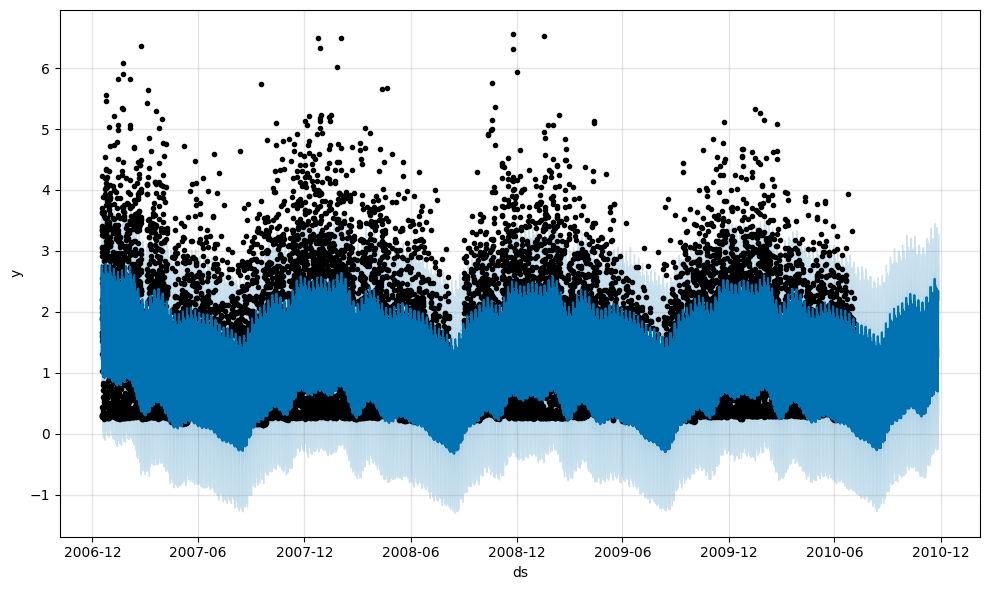

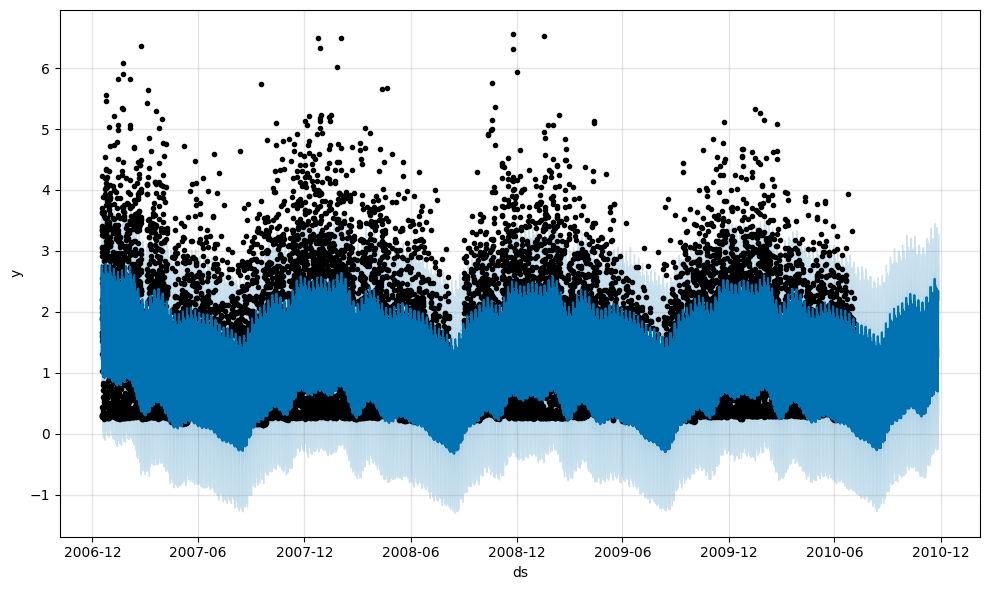

In [12]:
model.plot(forecast)

## Output

- Black dots → actual
- Blue line → prediction
- Light blue → confidence interval

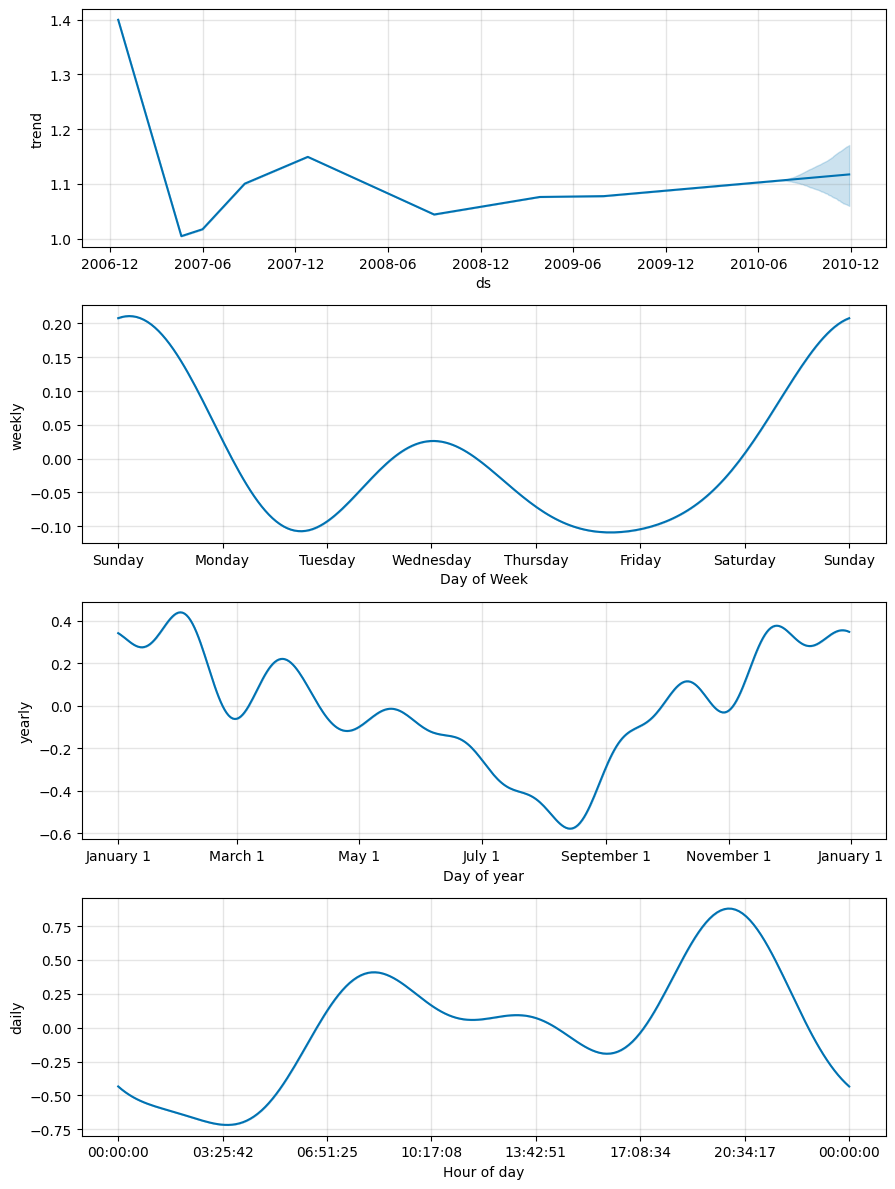

In [13]:
model.plot_components(forecast);

### Model Evaluation Strategy

The model was evaluated by forecasting the entire test set and comparing predictions with actual values using MAE and RMSE. 

A separate 24-hour forecast was generated to meet the project requirement for short-term prediction.

In [14]:
forecast_test = forecast.iloc[-len(test):]

mae = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.49337950448162626
RMSE: 0.6395071663668623


### Model Evaluation

The Prophet model was evaluated using MAE and RMSE.

- MAE measures average error magnitude
- RMSE penalizes larger errors more heavily

The results indicate that the model captures overall trends and seasonality effectively.

In [15]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.689855,0.745494,2.602233
34566,2010-11-25 23:00:00,1.246757,0.286770,2.183454
34567,2010-11-26 00:00:00,0.955451,0.037609,1.927665
34568,2010-11-26 01:00:00,0.826048,-0.155699,1.778067
34569,2010-11-26 02:00:00,0.758738,-0.138767,1.771306
34570,2010-11-26 03:00:00,0.693978,-0.224098,1.737371
34571,2010-11-26 04:00:00,0.691144,-0.243504,1.618226
34572,2010-11-26 05:00:00,0.855752,-0.035985,1.766670
34573,2010-11-26 06:00:00,1.197422,0.254514,2.150048
34574,2010-11-26 07:00:00,1.574964,0.655675,2.535757


In [16]:
future_24 = model.make_future_dataframe(periods=24, freq='h')
forecast_24 = model.predict(future_24)

forecast_24[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
31130,2010-07-05 19:00:00,1.374835,0.352786,2.262135
31131,2010-07-05 20:00:00,1.568846,0.647707,2.474476
31132,2010-07-05 21:00:00,1.411675,0.453628,2.366463
31133,2010-07-05 22:00:00,0.996440,0.108275,1.982791
31134,2010-07-05 23:00:00,0.555406,-0.396316,1.582070
31135,2010-07-06 00:00:00,0.266623,-0.635436,1.180619
31136,2010-07-06 01:00:00,0.140136,-0.732256,1.102172
31137,2010-07-06 02:00:00,0.076066,-0.898828,1.017167
31138,2010-07-06 03:00:00,0.014794,-0.981511,0.993914
31139,2010-07-06 04:00:00,0.015617,-0.947823,0.960098


### Key Observations

- Prophet effectively captures daily and weekly seasonality.
- The model provides uncertainty intervals, which are useful for decision-making.
- Forecasts align well with historical trends.